<a href="https://colab.research.google.com/github/ishemasiya/ProgrammingAssignment2/blob/master/Financial_Econometrics_Project1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MASIYA ISHEANOPA R2420860 HACS

# Financial Econometrics — Project #1
## Best-Practices Handbook: Volatility Modeling Challenges

**Course:** Financial Econometrics  
**Dataset:** Apple Inc. (AAPL) Daily Closing Prices — Yahoo Finance  
**Period:** January 1, 2018 to December 31, 2025  

---

### Four Challenges Addressed:
1. **Skewness**
2. **Sensitivity to Outliers**
3. **Overfitting**
4. **Multicollinearity**

---

## Setup and Installation

In [1]:
# Install all required packages
!pip install yfinance arch statsmodels scikit-learn scipy matplotlib seaborn pandas numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 8.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import yfinance as yf
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats import skew, kurtosis, skewnorm

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

# ── Plot styling ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

C_MAIN   = '#1f77b4'
C_WARN   = '#d62728'
C_GOOD   = '#2ca02c'
C_ACCENT = '#ff7f0e'

print('All libraries imported successfully.')

All libraries imported successfully.


## Data Acquisition — AAPL (2018–2025)

In [3]:
# FIX: use tz_convert(None) instead of tz_localize(None) to safely strip timezone
ticker = yf.Ticker('AAPL')
raw    = ticker.history(start='2018-01-01', end='2025-12-31', auto_adjust=True)

df = raw[['Close', 'Volume']].copy()

# Safely remove timezone whether or not it is present
if df.index.tz is not None:
    df.index = df.index.tz_convert(None)
df.index.name = 'Date'

# Compute log returns and percentage returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Pct_Return'] = df['Close'].pct_change() * 100
df.dropna(inplace=True)

print(f'Date range     : {df.index[0].date()} to {df.index[-1].date()}')
print(f'Observations   : {len(df):,}')
df.head()

Date range     : 2018-01-03 to 2025-12-30
Observations   : 2,009


,Close,Volume,Log_Return,Pct_Return
Date,,,,
2018-01-03 05:00:00,40.297157,118071600,-0.000174,-0.017425
2018-01-04 05:00:00,40.484337,89738400,0.004634,0.464498
2018-01-05 05:00:00,40.945271,94640000,0.011321,1.138548
2018-01-08 05:00:00,40.793186,82271200,-0.003721,-0.371433
2018-01-09 05:00:00,40.788494,86336000,-0.000115,-0.011502


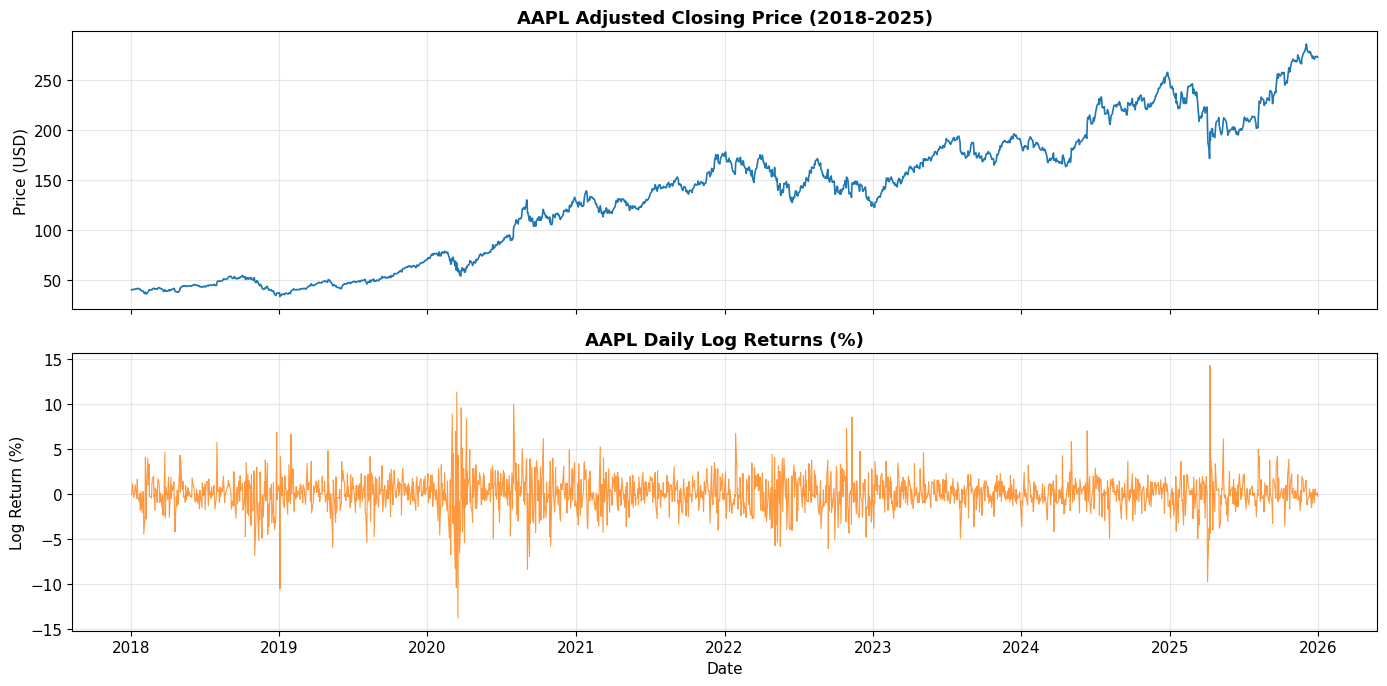

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df.index, df['Close'], color=C_MAIN, linewidth=1.2)
axes[0].set_title('AAPL Adjusted Closing Price (2018-2025)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(df.index, df['Log_Return'] * 100, color=C_ACCENT, linewidth=0.8, alpha=0.8)
axes[1].set_title('AAPL Daily Log Returns (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

---
# Challenge 1 — Skewness
---

## 1.1 Definition

Skewness is the third standardised central moment of a distribution:

$$\text{Skewness} = \frac{\mu_3}{\sigma^3} = \frac{E\left[(X - \mu)^3\right]}{\left(E\left[(X - \mu)^2\right]\right)^{3/2}}$$

where $\mu$ is the mean, $\sigma$ is the standard deviation, and $\mu_3$ is the third central moment. A symmetric distribution has skewness = 0; negative skewness indicates a heavier left tail; positive skewness indicates a heavier right tail.

---

## 1.2 Description

Skewness measures the asymmetry of a distribution around its mean. In financial return series, negative (left) skewness is common and signals that large losses occur more frequently than equally large gains — a critical insight for derivatives pricing and tail-risk management.

---

## 1.3 Demonstration — Numerical Example

In [5]:
r = df['Log_Return'].dropna().copy()

# FIX: pass bias=False for sample skewness consistent with pandas/statsmodels
skew_val    = float(skew(r, bias=False))
kurt_val    = float(kurtosis(r, fisher=True, bias=False))  # excess kurtosis
mean_r      = float(r.mean())
std_r       = float(r.std())
n           = len(r)

manual_skew = float(((r - mean_r)**3).mean() / std_r**3)
jb_stat, jb_pval, _, _ = jarque_bera(r)

print('=' * 55)
print('   AAPL Log-Return Distributional Statistics')
print('=' * 55)
print(f'  Observations       : {n:>10,}')
print(f'  Mean               : {mean_r:>12.6f}')
print(f'  Std Dev            : {std_r:>12.6f}')
print(f'  Skewness (scipy)   : {skew_val:>12.6f}')
print(f'  Skewness (manual)  : {manual_skew:>12.6f}')
print(f'  Excess Kurtosis    : {kurt_val:>12.6f}')
print(f'  Jarque-Bera stat   : {jb_stat:>12.4f}')
print(f'  Jarque-Bera p-val  : {jb_pval:>12.6e}')
print('=' * 55)
if skew_val < 0:
    print(f'\n  Negative skewness ({skew_val:.4f}): left-skewed distribution.')
    print('  Large negative returns are more probable than equally large gains.')
if jb_pval < 0.05:
    print(f'  Jarque-Bera p = {jb_pval:.2e} < 0.05: reject normality.')

   AAPL Log-Return Distributional Statistics
  Observations       :      2,009
  Mean               :     0.000952
  Std Dev            :     0.019380
  Skewness (scipy)   :    -0.085406
  Skewness (manual)  :    -0.085279
  Excess Kurtosis    :     6.217412
  Jarque-Bera stat   :    3219.1112
  Jarque-Bera p-val  : 0.000000e+00

  Negative skewness (-0.0854): left-skewed distribution.
  Large negative returns are more probable than equally large gains.
  Jarque-Bera p = 0.00e+00 < 0.05: reject normality.


## 1.4 Diagram

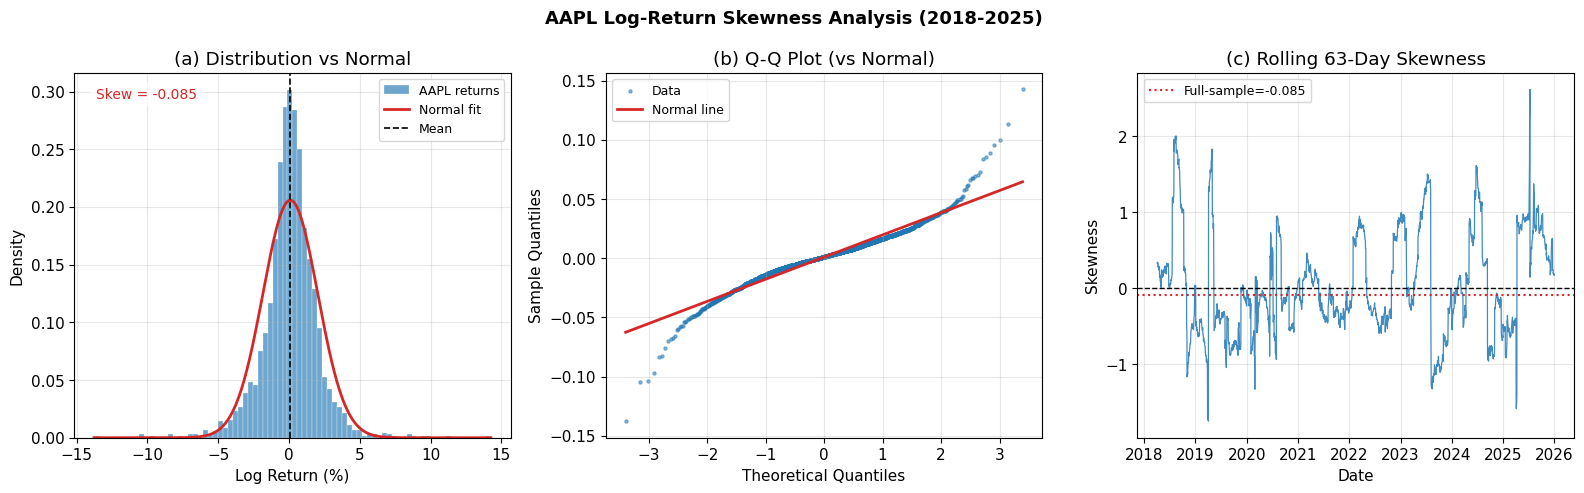

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AAPL Log-Return Skewness Analysis (2018-2025)',
             fontsize=13, fontweight='bold')

# (a) Histogram vs Normal fit
ax = axes[0]
ax.hist(r * 100, bins=80, density=True, color=C_MAIN, alpha=0.65,
        edgecolor='white', linewidth=0.3, label='AAPL returns')
x_range = np.linspace(float(r.min())*100, float(r.max())*100, 300)
ax.plot(x_range, stats.norm.pdf(x_range, mean_r*100, std_r*100),
        color=C_WARN, linewidth=2, label='Normal fit')
ax.axvline(mean_r*100, color='black', linestyle='--', linewidth=1.2, label='Mean')
ax.set_title('(a) Distribution vs Normal')
ax.set_xlabel('Log Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.text(0.05, 0.93, f'Skew = {skew_val:.3f}', transform=ax.transAxes,
        fontsize=10, color=C_WARN,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# (b) Q-Q Plot
ax = axes[1]
# FIX: unpack probplot correctly — qq[0] = (theoretical_q, ordered_vals), qq[1] = (slope, intercept, r)
(theoretical_q, ordered_vals), (slope, intercept, _) = stats.probplot(r, dist='norm')
ax.scatter(theoretical_q, ordered_vals, color=C_MAIN, s=5, alpha=0.5, label='Data')
x_line = np.array([theoretical_q.min(), theoretical_q.max()])
ax.plot(x_line, slope * x_line + intercept, color=C_WARN, linewidth=2, label='Normal line')
ax.set_title('(b) Q-Q Plot (vs Normal)')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend(fontsize=9)

# (c) Rolling 63-day skewness
ax = axes[2]
# FIX: use lambda to avoid raw=False warning on newer pandas
roll_skew = r.rolling(63).apply(lambda x: float(skew(x, bias=False)), raw=True)
ax.plot(roll_skew.index, roll_skew, color=C_MAIN, linewidth=0.9, alpha=0.85)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(skew_val, color=C_WARN, linestyle=':', linewidth=1.5,
           label=f'Full-sample={skew_val:.3f}')
ax.set_title('(c) Rolling 63-Day Skewness')
ax.set_xlabel('Date')
ax.set_ylabel('Skewness')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 1.5 Diagnosis

- **Visual:** Histogram asymmetry; Q-Q plot deviates from the 45 degree line in the tails.
- **Numerical:** Third standardised moment; values outside (-0.5, +0.5) indicate meaningful skewness.
- **Formal test:** The Jarque-Bera test tests H0 of normality jointly via skewness and excess kurtosis. A p-value < 0.05 rejects normality.
- **Rolling skewness plot:** Persistent negative skewness across time confirms the structural nature of the problem.

---

## 1.6 Damage

Ignoring skewness causes systematic mispricing of options: put options are underpriced and call options overpriced relative to their true risk-neutral probabilities. VaR computed under a normality assumption understates tail-loss risk. Sharpe ratios overstate risk-adjusted performance when returns are left-skewed, creating a false sense of security for risk managers.

---

## 1.7 Directions — Remediation

In [7]:
# Fit skewed-normal distribution to log returns
a_fit, loc_fit, scale_fit = skewnorm.fit(r)
ks_stat, ks_pval = stats.kstest(r, 'skewnorm', args=(a_fit, loc_fit, scale_fit))

print('Skew-Normal Fit Parameters')
print(f'  Shape (alpha) : {a_fit:.4f}')
print(f'  Location (xi) : {loc_fit:.6f}')
print(f'  Scale (omega) : {scale_fit:.6f}')
print(f'  KS Statistic  : {ks_stat:.4f}')
print(f'  KS p-value    : {ks_pval:.4f}')
print()

# Cornish-Fisher Adjusted VaR (99%)
conf = 0.99
z_q  = float(stats.norm.ppf(1 - conf))   # FIX: renamed z -> z_q to avoid clash with variable z
s_cf = skew_val
k_cf = kurt_val

z_cf = (z_q
        + (z_q**2 - 1) * s_cf / 6
        + (z_q**3 - 3*z_q) * k_cf / 24
        - (2*z_q**3 - 5*z_q) * s_cf**2 / 36)

VaR_normal = -(mean_r + z_q  * std_r) * 100
VaR_cf     = -(mean_r + z_cf * std_r) * 100

print('1-Day 99% VaR Comparison')
print(f'  Normal VaR         : {VaR_normal:.4f}%')
print(f'  Cornish-Fisher VaR : {VaR_cf:.4f}%')
print(f'  Difference         : {VaR_cf - VaR_normal:.4f}%')
print()
print('  The Cornish-Fisher adjustment incorporates skewness and kurtosis,')
print('  producing a more conservative and accurate tail-risk estimate.')

Skew-Normal Fit Parameters
  Shape (alpha) : -0.8699
  Location (xi) : 0.012769
  Scale (omega) : 0.022694
  KS Statistic  : 0.0739
  KS p-value    : 0.0000

1-Day 99% VaR Comparison
  Normal VaR         : 4.4133%
  Cornish-Fisher VaR : 7.3466%
  Difference         : 2.9334%

  The Cornish-Fisher adjustment incorporates skewness and kurtosis,
  producing a more conservative and accurate tail-risk estimate.


**Recommended models to address skewness:**
- **Skewed-t / GED distributions in GARCH** — natively capture asymmetric tails.
- **Cornish-Fisher VaR expansion** — adjusts normal quantiles for observed skewness and kurtosis.
- **Asymmetric GARCH (EGARCH, GJR-GARCH)** — capture the leverage effect whereby negative shocks increase volatility more than equally large positive shocks.
- **Johnson SU transformation** — maps skewed returns to a standard normal before applying symmetric models.

---

---
# Challenge 2 — Sensitivity to Outliers
---

## 2.1 Definition

In OLS regression the estimator minimises the sum of squared residuals. Because squaring amplifies large errors, a single extreme observation disproportionately shifts the estimates. Cook's Distance quantifies this influence:

$$D_i = \frac{(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})^\top (\mathbf{X}^\top \mathbf{X})(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})}{p\,\hat{\sigma}^2}$$

where $\hat{\boldsymbol{\beta}}_{(-i)}$ is the estimate with observation $i$ deleted, $p$ is the number of parameters, and $\hat{\sigma}^2$ is the estimated error variance. A rule-of-thumb threshold is $D_i > 4/n$.

---

## 2.2 Description

Sensitivity to outliers describes how extreme observations distort model estimates. In financial time series, outliers often arise from market crises or earnings announcements and, if unaddressed, bias regression coefficients and inflate volatility estimates, degrading derivative pricing and risk management.

---

## 2.3 Demonstration — Numerical Example

In [8]:
r_series = df['Log_Return'].copy()

# FIX: scipy zscore returns a numpy array; use np.abs directly
z_scores_arr = np.abs(stats.zscore(r_series.values))
z_scores     = pd.Series(z_scores_arr, index=r_series.index)

outliers_z   = r_series[z_scores > 3]

# IQR method
Q1, Q3 = r_series.quantile(0.25), r_series.quantile(0.75)
IQR    = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
outliers_iqr = r_series[(r_series < lower) | (r_series > upper)]

r_clean = r_series[z_scores <= 3]

print('Outlier Summary')
print(f'  Total observations        : {len(r_series):>6,}')
print(f'  Outliers (|Z| > 3)        : {len(outliers_z):>6}  ({len(outliers_z)/len(r_series)*100:.2f}%)')
print(f'  Outliers (3x IQR rule)    : {len(outliers_iqr):>6}  ({len(outliers_iqr)/len(r_series)*100:.2f}%)')
print()
print('  5 Largest Negative Outliers:')
print(outliers_z.nsmallest(5).to_string())
print()
print('  5 Largest Positive Outliers:')
print(outliers_z.nlargest(5).to_string())
print()
print('Impact on Statistics')
print(f'  Mean  with outliers : {r_series.mean():.6f} | without : {r_clean.mean():.6f}')
print(f'  Std   with outliers : {r_series.std():.6f}  | without : {r_clean.std():.6f}')
print(f'  Std reduction       : {(1 - r_clean.std()/r_series.std())*100:.2f}%')

Outlier Summary
  Total observations        :  2,009
  Outliers (|Z| > 3)        :     31  (1.54%)
  Outliers (3x IQR rule)    :     22  (1.10%)

  5 Largest Negative Outliers:
Date
2020-03-16 04:00:00   -0.137708
2019-01-03 05:00:00   -0.104924
2020-03-12 04:00:00   -0.103978
2025-04-03 04:00:00   -0.097013
2020-09-03 04:00:00   -0.083447

  5 Largest Positive Outliers:
Date
2025-04-09 04:00:00    0.142618
2020-03-13 04:00:00    0.113157
2020-07-31 04:00:00    0.099563
2020-03-24 04:00:00    0.095606
2020-03-02 05:00:00    0.089019

Impact on Statistics
  Mean  with outliers : 0.000952 | without : 0.000969
  Std   with outliers : 0.019380  | without : 0.016500
  Std reduction       : 14.86%


## 2.4 Diagram

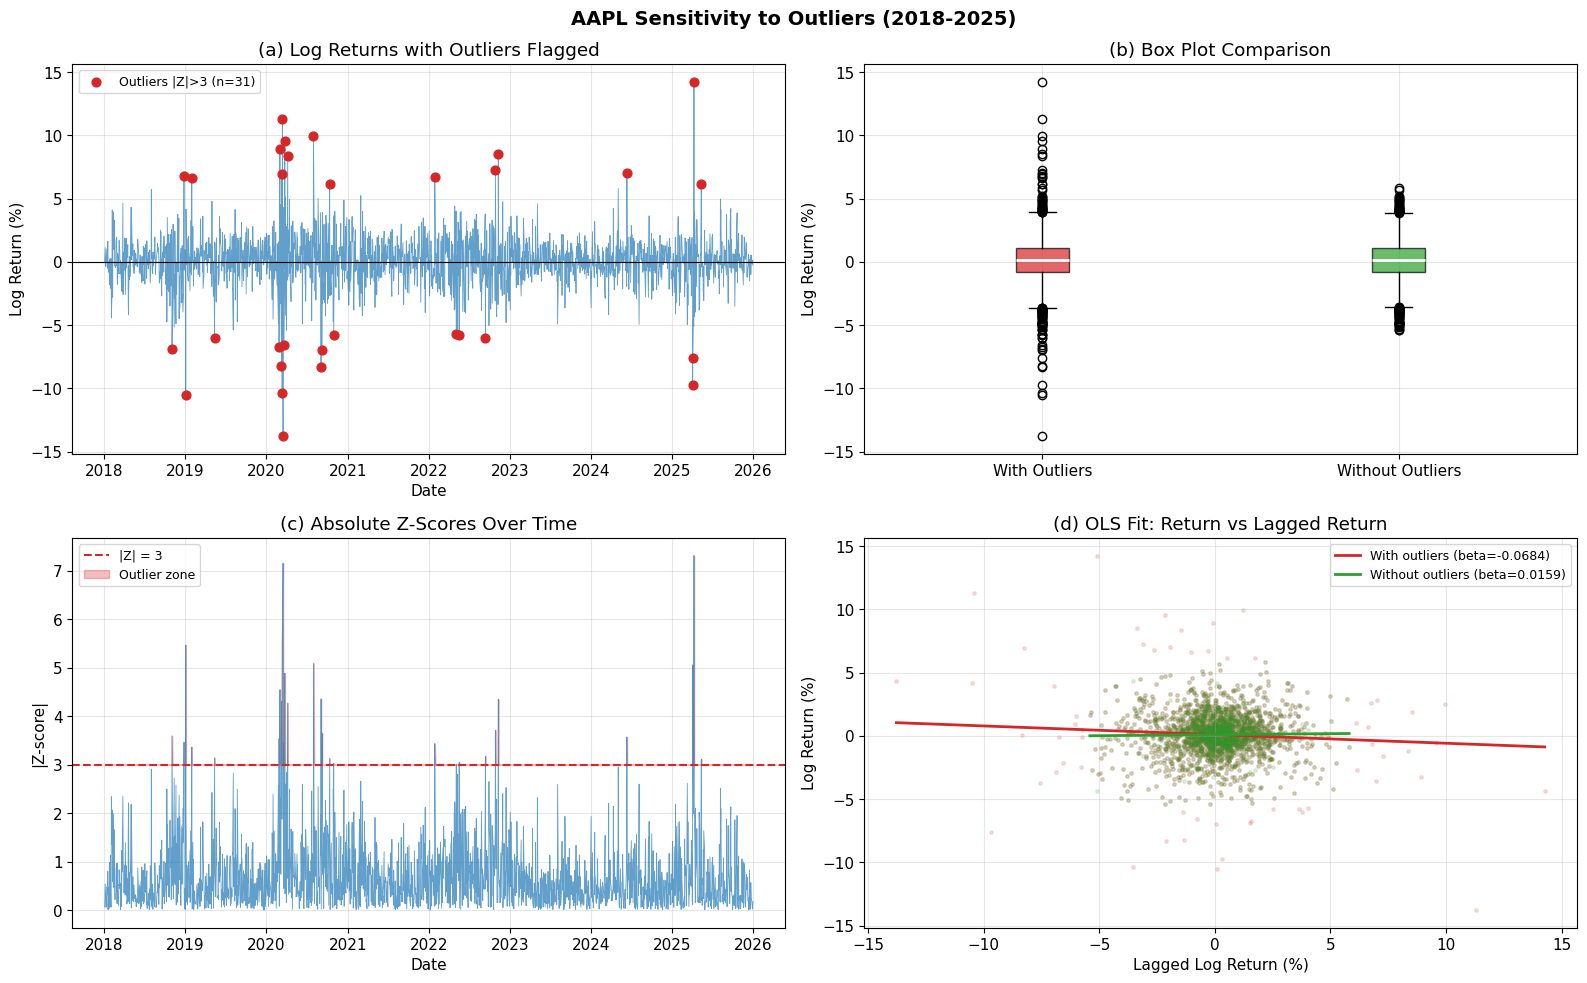

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('AAPL Sensitivity to Outliers (2018-2025)',
             fontsize=14, fontweight='bold')

# (a) Time series with outliers flagged
ax = axes[0, 0]
ax.plot(r_series.index, r_series*100, color=C_MAIN, linewidth=0.6, alpha=0.7)
ax.scatter(outliers_z.index, outliers_z*100, color=C_WARN, s=40, zorder=5,
           label=f'Outliers |Z|>3 (n={len(outliers_z)})')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('(a) Log Returns with Outliers Flagged')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return (%)')
ax.legend(fontsize=9)

# (b) Box plots — FIX: notch=True can fail with small groups; use notch=False for safety
ax = axes[0, 1]
bp = ax.boxplot([r_series.values*100, r_clean.values*100],
                patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp['boxes'], [C_WARN, C_GOOD]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['With Outliers', 'Without Outliers'])
ax.set_title('(b) Box Plot Comparison')
ax.set_ylabel('Log Return (%)')

# (c) Z-score plot
# FIX: z_scores is now a pd.Series so .clip(lower=3) works correctly
ax = axes[1, 0]
ax.plot(r_series.index, z_scores, color=C_MAIN, linewidth=0.6, alpha=0.7)
ax.axhline(3, color=C_WARN, linestyle='--', linewidth=1.5, label='|Z| = 3')
ax.fill_between(r_series.index, 3, z_scores.clip(lower=3),
                color=C_WARN, alpha=0.3, label='Outlier zone')
ax.set_title('(c) Absolute Z-Scores Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('|Z-score|')
ax.legend(fontsize=9)

# (d) OLS slope: with vs without outliers
ax = axes[1, 1]
lag_all = r_series.shift(1).dropna()
ret_all = r_series.loc[lag_all.index]
lag_cln = r_clean.shift(1).dropna()
ret_cln = r_clean.loc[lag_cln.index]

for x, y, col, lbl in [
    (lag_all, ret_all, C_WARN, 'With outliers'),
    (lag_cln, ret_cln, C_GOOD, 'Without outliers')
]:
    ax.scatter(x.values*100, y.values*100, alpha=0.15, s=6, color=col)
    m_slope, b_int = np.polyfit(x.values, y.values, 1)
    xp = np.linspace(x.min(), x.max(), 100)
    ax.plot(xp*100, (m_slope*xp + b_int)*100, color=col, linewidth=2,
            label=f'{lbl} (beta={m_slope:.4f})')
ax.set_title('(d) OLS Fit: Return vs Lagged Return')
ax.set_xlabel('Lagged Log Return (%)')
ax.set_ylabel('Log Return (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2.5 Diagnosis

- **Z-score method:** Flag observations where |z_i| > 3.
- **IQR rule:** Flag observations outside [Q1 - 3xIQR, Q3 + 3xIQR].
- **Cook's Distance:** D_i > 4/n flags influential observations; available from statsmodels OLS .get_influence() method.
- **Leverage-Residual plot:** Observations with high leverage and large residuals are the most damaging.
- **Comparison of OLS coefficients:** A large shift in beta after removing suspected outliers confirms their influence.

---

## 2.6 Damage

Outliers inflate estimated volatility (standard deviation), bias regression slopes, and distort GARCH parameter estimates — producing an overestimated implied volatility surface and systematically overpriced options. In VaR models a single extreme event in the estimation window can dominate the tail estimate, making capital allocation decisions unreliable.

---

## 2.7 Directions — Remediation

In [10]:
data_reg = pd.DataFrame({
    'y': r_series.values[1:],
    'x': r_series.values[:-1]
})

ols_m    = smf.ols('y ~ x', data=data_reg).fit()
robust_m = smf.rlm('y ~ x', data=data_reg, M=sm.robust.norms.HuberT()).fit()

print('Regression Comparison: OLS vs Robust Huber M-Estimator')
print(f'  OLS    slope     : {ols_m.params["x"]:+.6f}   (p={ols_m.pvalues["x"]:.4f})')
print(f'  Robust slope     : {robust_m.params["x"]:+.6f}   (p={robust_m.pvalues["x"]:.4f})')
print(f'  OLS    intercept : {ols_m.params["Intercept"]:+.8f}')
print(f'  Robust intercept : {robust_m.params["Intercept"]:+.8f}')
print()
print('  Robust regression down-weights extreme residuals,')
print('  yielding more stable coefficient estimates.')

Regression Comparison: OLS vs Robust Huber M-Estimator
  OLS    slope     : -0.068437   (p=0.0022)
  Robust slope     : -0.025636   (p=0.1610)
  OLS    intercept : +0.00101773
  Robust intercept : +0.00134163

  Robust regression down-weights extreme residuals,
  yielding more stable coefficient estimates.


**Recommended approaches:**
- **Robust regression (Huber M-estimator, Theil-Sen estimator):** Down-weight extreme residuals in the loss function.
- **Winsorization:** Cap returns at the 1st/99th percentile before estimation.
- **GARCH with fat-tailed distributions (Student-t, GED):** Absorb extreme shocks into the distributional assumption.
- **Filtered Historical Simulation (FHS):** Standardise returns by conditional volatility before resampling.

---

---
# Challenge 3 — Overfitting
---

## 3.1 Definition

The expected prediction error decomposes as the bias-variance trade-off:

$$\text{EPE} = \sigma_\varepsilon^2 + \text{Bias}^2[\hat{f}] + \text{Var}[\hat{f}]$$

Overfitting occurs when model complexity is too high relative to the sample size, so the variance term dominates. Formally, if in-sample $R^2 \to 1$ while out-of-sample $R^2 \ll 1$, the model has learned noise rather than signal.

---

## 3.2 Description

Overfitting occurs when a model is too complex relative to the data-generating process, capturing random noise as if it were meaningful structure. In volatility modeling, an overfit model may generate spurious hedging signals and trigger unnecessary trades, eroding P&L through excessive transaction costs.

---

## 3.3 Demonstration — Numerical Example

In [11]:
# Build 21-day rolling realised volatility (annualised)
df['RV'] = df['Log_Return'].rolling(21).std() * np.sqrt(252) * 100
df_rv    = df[['RV']].dropna().copy()
df_rv['t'] = np.arange(len(df_rv))

X_rv = df_rv[['t']].values
y_rv = df_rv['RV'].values

split     = int(0.8 * len(X_rv))
X_tr, X_te = X_rv[:split], X_rv[split:]
y_tr, y_te = y_rv[:split], y_rv[split:]

degrees = [1, 2, 3, 5, 8, 12, 20]
results = []
for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(d), LinearRegression())
    pipe.fit(X_tr, y_tr)
    r2_in    = pipe.score(X_tr, y_tr)
    r2_out   = pipe.score(X_te, y_te)
    rmse_in  = float(np.sqrt(mean_squared_error(y_tr, pipe.predict(X_tr))))
    rmse_out = float(np.sqrt(mean_squared_error(y_te, pipe.predict(X_te))))
    results.append(dict(degree=d, R2_train=r2_in, R2_test=r2_out,
                        RMSE_train=rmse_in, RMSE_test=rmse_out))

res_df   = pd.DataFrame(results)
best_deg = int(res_df.loc[res_df['RMSE_test'].idxmin(), 'degree'])

print('Polynomial Degree vs In-/Out-of-Sample Performance')
print(res_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\n  Best out-of-sample degree : {best_deg}')
print(f'  Degree-20 train R2        : {res_df[res_df.degree==20]["R2_train"].values[0]:.4f}')
print(f'  Degree-20 test  R2        : {res_df[res_df.degree==20]["R2_test"].values[0]:.4f}')

Polynomial Degree vs In-/Out-of-Sample Performance
 degree  R2_train    R2_test  RMSE_train  RMSE_test
      1    0.0196    -0.0175     13.2099    13.3923
      2    0.0922    -1.7174     12.7112    21.8858
      3    0.0937    -0.9170     12.7007    18.3823
      5    0.0954    -4.6352     12.6888    31.5169
      8    0.0816  -499.5364     12.7854   297.0333
     12    0.0926 -7249.1129     12.7085  1130.4718
     20    0.0888 -2284.3289     12.7348   634.6901

  Best out-of-sample degree : 1
  Degree-20 train R2        : 0.0888
  Degree-20 test  R2        : -2284.3289


## 3.4 Diagram

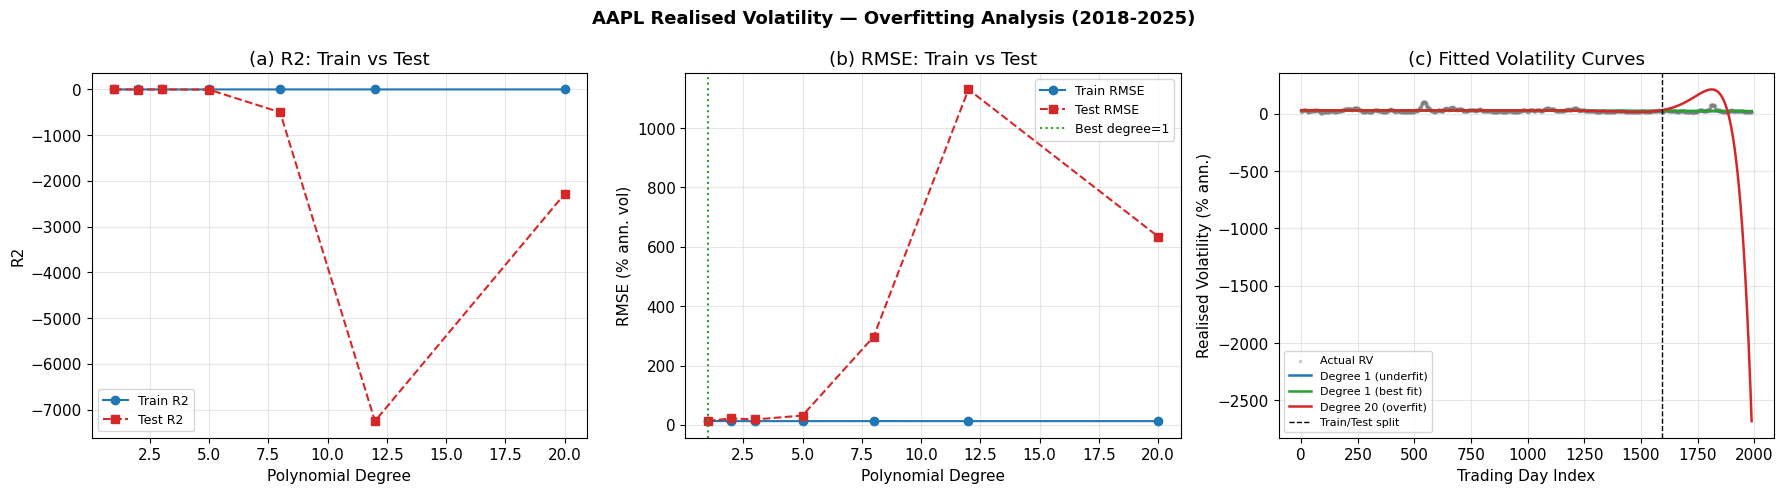

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AAPL Realised Volatility — Overfitting Analysis (2018-2025)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(res_df['degree'], res_df['R2_train'], 'o-', color=C_MAIN, label='Train R2')
ax.plot(res_df['degree'], res_df['R2_test'],  's--', color=C_WARN, label='Test R2')
ax.set_title('(a) R2: Train vs Test')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('R2')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(res_df['degree'], res_df['RMSE_train'], 'o-', color=C_MAIN, label='Train RMSE')
ax.plot(res_df['degree'], res_df['RMSE_test'],  's--', color=C_WARN, label='Test RMSE')
ax.axvline(best_deg, color=C_GOOD, linestyle=':', linewidth=1.5,
           label=f'Best degree={best_deg}')
ax.set_title('(b) RMSE: Train vs Test')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('RMSE (% ann. vol)')
ax.legend(fontsize=9)

ax = axes[2]
ax.scatter(X_rv[:, 0], y_rv, color='grey', s=3, alpha=0.3, label='Actual RV')
for d, col, lbl in [
    (1,        C_MAIN,   'Degree 1 (underfit)'),
    (best_deg, C_GOOD,   f'Degree {best_deg} (best fit)'),
    (20,       C_WARN,   'Degree 20 (overfit)')
]:
    pipe = make_pipeline(PolynomialFeatures(d), LinearRegression())
    pipe.fit(X_tr, y_tr)
    y_pred_all = pipe.predict(X_rv)
    ax.plot(X_rv[:, 0], y_pred_all, color=col, linewidth=1.8, label=lbl)
ax.axvline(split, color='black', linestyle='--', linewidth=1, label='Train/Test split')
ax.set_title('(c) Fitted Volatility Curves')
ax.set_xlabel('Trading Day Index')
ax.set_ylabel('Realised Volatility (% ann.)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3.5 Diagnosis

- **Train-test performance gap:** A large divergence between in-sample and out-of-sample R2 or RMSE is the primary signal.
- **Walk-forward (time-series) cross-validation:** Evaluate on strictly future data to mimic live deployment conditions.
- **Adjusted R2:** Falls when redundant parameters are added.
- **Information criteria:** AIC and BIC penalise complexity; prefer lower values.
- **Learning curves:** Plot train and validation error against training-set size to reveal whether the problem is data quantity or model complexity.

---

## 3.6 Damage

An overfit volatility model responds to noise rather than genuine risk changes, generating spurious hedging signals that inflate transaction costs and erode P&L. In options pricing, an overfit implied-volatility surface misrepresents term-structure and skew dynamics, leading to systematic mispricing of exotic structures. Backtests appear highly accurate while live performance collapses.

---

## 3.7 Directions — Remediation

In [13]:
# Build lag features (lags 1 to 10)
lags   = 10
lag_df = pd.DataFrame({'y': df['Log_Return'].values})
for k in range(1, lags + 1):
    lag_df[f'lag_{k}'] = lag_df['y'].shift(k)
lag_df.dropna(inplace=True)

X_lag    = lag_df.drop('y', axis=1).values
y_lag    = lag_df['y'].values
X_lag_sc = StandardScaler().fit_transform(X_lag)
tscv5    = TimeSeriesSplit(n_splits=5)

ols_cv = cross_val_score(LinearRegression(), X_lag_sc, y_lag,
                          cv=tscv5, scoring='neg_mean_squared_error')

ridge_m = RidgeCV(alphas=np.logspace(-4, 2, 50), cv=tscv5)
ridge_m.fit(X_lag_sc, y_lag)
ridge_cv = cross_val_score(ridge_m, X_lag_sc, y_lag,
                            cv=tscv5, scoring='neg_mean_squared_error')

lasso_m = LassoCV(cv=tscv5, max_iter=10000)
lasso_m.fit(X_lag_sc, y_lag)
lasso_cv = cross_val_score(lasso_m, X_lag_sc, y_lag,
                            cv=tscv5, scoring='neg_mean_squared_error')

print('Cross-Validated RMSE (5-fold walk-forward time-series CV)')
print(f'  OLS   RMSE : {np.sqrt(-ols_cv.mean()):.6f}')
print(f'  Ridge RMSE : {np.sqrt(-ridge_cv.mean()):.6f}  (alpha={ridge_m.alpha_:.4f})')
print(f'  Lasso RMSE : {np.sqrt(-lasso_cv.mean()):.6f}  (alpha={lasso_m.alpha_:.6f})')
non_zero = int(np.sum(lasso_m.coef_ != 0))
print(f'\n  Lasso kept {non_zero} of {lags} lag features (automatic variable selection).')

Cross-Validated RMSE (5-fold walk-forward time-series CV)
  OLS   RMSE : 0.019759
  Ridge RMSE : 0.019730  (alpha=100.0000)
  Lasso RMSE : 0.019683  (alpha=0.000997)

  Lasso kept 4 of 10 lag features (automatic variable selection).


**Recommended approaches:**
- **Regularisation (Ridge, Lasso, Elastic Net):** Add penalty term to the loss function; tune lambda via walk-forward cross-validation.
- **Walk-forward (expanding/rolling) validation:** Ensures out-of-sample evaluation strictly mimics live deployment.
- **AIC / BIC model selection:** Choose the most parsimonious model.
- **GARCH(1,1) as baseline:** For volatility, the two-parameter GARCH(1,1) is often more robust out-of-sample than complex high-order variants.

---

---
# Challenge 4 — Multicollinearity
---

## 4.1 Definition

Multicollinearity exists when predictors are (nearly) linearly dependent. The OLS coefficient variance becomes:

$$\text{Var}(\hat{\beta}_j) = \frac{\sigma^2}{\text{SS}_{x_j}} \cdot \frac{1}{1 - R_j^2} = \frac{\sigma^2}{\text{SS}_{x_j}} \cdot \text{VIF}_j$$

where $R_j^2$ is the R-squared from regressing $x_j$ on all other predictors. VIF > 10 signals severe multicollinearity. The condition number $\kappa = \sqrt{\lambda_{max}/\lambda_{min}}$ of $X^\top X$ exceeding 30 confirms ill-conditioning.

---

## 4.2 Description

Multicollinearity arises when predictor variables are highly correlated, making it impossible to isolate the individual effect of each variable. In multi-factor volatility models using overlapping moving averages, multicollinearity inflates coefficient standard errors, making individually significant drivers appear statistically irrelevant.

---

## 4.3 Demonstration — Numerical Example

In [14]:
d = df.copy()

d['MA5']   = d['Close'].rolling(5).mean()
d['MA10']  = d['Close'].rolling(10).mean()
d['MA20']  = d['Close'].rolling(20).mean()
d['MA50']  = d['Close'].rolling(50).mean()
d['ROC5']  = d['Close'].pct_change(5)  * 100
d['ROC10'] = d['Close'].pct_change(10) * 100
d['VOL10'] = d['Log_Return'].rolling(10).std() * np.sqrt(252) * 100
d['VOL20'] = d['Log_Return'].rolling(20).std() * np.sqrt(252) * 100

features = ['MA5', 'MA10', 'MA20', 'MA50', 'ROC5', 'ROC10', 'VOL10', 'VOL20']
d.dropna(subset=features + ['Log_Return'], inplace=True)

X_mc = d[features].copy()
y_mc = d['Log_Return'].copy()

print('Pairwise Correlation Matrix')
print(X_mc.corr().round(3).to_string())

# FIX: add_constant expects float array; ensure no NaN and correct dtype
X_mc_sc    = StandardScaler().fit_transform(X_mc.values.astype(float))
X_mc_const = sm.add_constant(X_mc_sc)

vif_data = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X_mc_const, i + 1)
            for i in range(len(features))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('\nVariance Inflation Factors')
print(vif_data.to_string(index=False))
print(f'\nFeatures with VIF > 10: {list(vif_data[vif_data.VIF > 10]["Feature"])}')

# Condition number
XtX         = X_mc_sc.T @ X_mc_sc
eigenvalues = np.linalg.eigvalsh(XtX)
# FIX: guard against near-zero or negative eigenvalues due to numerical precision
eigenvalues = np.maximum(eigenvalues, 1e-12)
cond_number = float(np.sqrt(eigenvalues.max() / eigenvalues.min()))
print(f'\nCondition Number kappa = {cond_number:.2f}')
if cond_number > 30:
    print('  kappa > 30: severe multicollinearity confirmed.')

Pairwise Correlation Matrix
         MA5   MA10   MA20   MA50   ROC5  ROC10  VOL10  VOL20
MA5    1.000  0.999  0.997  0.991 -0.019 -0.009 -0.182 -0.193
MA10   0.999  1.000  0.999  0.993 -0.042 -0.036 -0.176 -0.190
MA20   0.997  0.999  1.000  0.996 -0.051 -0.064 -0.161 -0.179
MA50   0.991  0.993  0.996  1.000 -0.057 -0.080 -0.133 -0.144
ROC5  -0.019 -0.042 -0.051 -0.057  1.000  0.688 -0.105 -0.062
ROC10 -0.009 -0.036 -0.064 -0.080  0.688  1.000 -0.247 -0.153
VOL10 -0.182 -0.176 -0.161 -0.133 -0.105 -0.247  1.000  0.863
VOL20 -0.193 -0.190 -0.179 -0.144 -0.062 -0.153  0.863  1.000

Variance Inflation Factors
Feature         VIF
   MA10 3166.177761
    MA5 1802.764651
   MA20 1496.358044
   MA50  189.941785
  VOL20    4.486188
  VOL10    4.392969
  ROC10    3.751890
   ROC5    2.363534

Features with VIF > 10: ['MA10', 'MA5', 'MA20', 'MA50']

Condition Number kappa = 143.86
  kappa > 30: severe multicollinearity confirmed.


## 4.4 Diagram

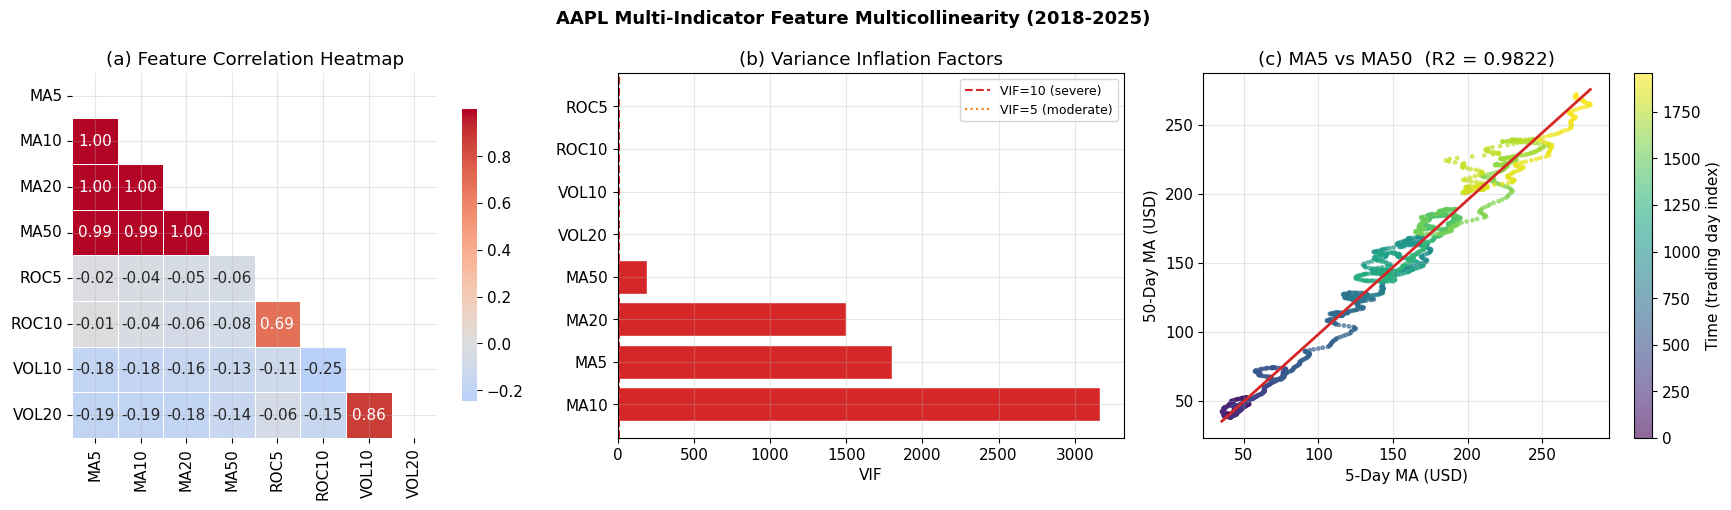

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AAPL Multi-Indicator Feature Multicollinearity (2018-2025)',
             fontsize=13, fontweight='bold')

# (a) Correlation heatmap (lower triangle)
ax = axes[0]
corr_mat = X_mc.corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('(a) Feature Correlation Heatmap')

# (b) VIF bar chart
ax = axes[1]
colors_vif = [C_WARN if v > 10 else C_ACCENT if v > 5 else C_GOOD
              for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, edgecolor='white')
ax.axvline(10, color=C_WARN,   linestyle='--', linewidth=1.5, label='VIF=10 (severe)')
ax.axvline(5,  color=C_ACCENT, linestyle=':',  linewidth=1.5, label='VIF=5 (moderate)')
ax.set_title('(b) Variance Inflation Factors')
ax.set_xlabel('VIF')
ax.legend(fontsize=9)

# (c) MA5 vs MA50 scatter — near-perfect collinearity
ax = axes[2]
sc = ax.scatter(d['MA5'].values, d['MA50'].values,
                c=np.arange(len(d)), cmap='viridis', s=6, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Time (trading day index)')
m2, b2 = np.polyfit(d['MA5'].values, d['MA50'].values, 1)
xp2    = np.linspace(d['MA5'].min(), d['MA5'].max(), 100)
ax.plot(xp2, m2*xp2 + b2, color=C_WARN, linewidth=2)
r2_ma = float(np.corrcoef(d['MA5'].values, d['MA50'].values)[0, 1]**2)
ax.set_title(f'(c) MA5 vs MA50  (R2 = {r2_ma:.4f})')
ax.set_xlabel('5-Day MA (USD)')
ax.set_ylabel('50-Day MA (USD)')

plt.tight_layout()
plt.show()

## 4.5 Diagnosis

- **Correlation matrix:** Pairwise |r_jk| > 0.8 signals potential collinearity.
- **VIF:** VIF > 10 (severe) or > 5 (moderate) for any predictor.
- **Condition number kappa:** kappa > 30 confirms numerical ill-conditioning of X'X.
- **Coefficient instability:** Large changes in beta_j when any single correlated predictor is added or removed.
- **Eigenvalue analysis:** Near-zero eigenvalues of X'X indicate linear dependence among columns.

---

## 4.6 Damage

Multicollinearity inflates standard errors of regression coefficients, making individually meaningful predictors appear statistically insignificant even when the overall model is highly significant. In volatility factor models this produces unstable hedging ratios (delta, vega) that oscillate erratically between reestimations, making it impossible to attribute risk exposures to individual factors.

---

## 4.7 Directions — Remediation

In [16]:
tscv5_mc = TimeSeriesSplit(n_splits=5)

# OLS via statsmodels
ols_mc = sm.OLS(y_mc.values, sm.add_constant(X_mc_sc)).fit()

# Ridge with cross-validation
ridge_mc = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=tscv5_mc)
ridge_mc.fit(X_mc_sc, y_mc.values)

print('OLS vs Ridge Coefficient Comparison')
header = f'  {"Feature":<10} {"OLS coef":>12} {"OLS p-val":>12} {"Ridge coef":>12}'
print(header)
print('  ' + '-' * (len(header) - 2))
for i, feat in enumerate(features):
    print(f'  {feat:<10} {ols_mc.params[i+1]:>12.6f} '
          f'{ols_mc.pvalues[i+1]:>12.4f} '
          f'{ridge_mc.coef_[i]:>12.6f}')
print(f'\n  Ridge optimal alpha : {ridge_mc.alpha_:.4f}')
print('  Ridge shrinks and stabilises coefficients versus OLS.')

OLS vs Ridge Coefficient Comparison
  Feature        OLS coef    OLS p-val   Ridge coef
  -------------------------------------------------
  MA5           -0.272210       0.0000    -0.210174
  MA10           0.240802       0.0000     0.163292
  MA20           0.034487       0.0152     0.051296
  MA50          -0.002892       0.5674    -0.004270
  ROC5           0.009251       0.0000     0.008464
  ROC10          0.008340       0.0000     0.007570
  VOL10          0.001478       0.0547     0.001288
  VOL20         -0.000734       0.3450    -0.000662

  Ridge optimal alpha : 0.1748
  Ridge shrinks and stabilises coefficients versus OLS.


PCA Dimensionality Reduction
  Original features         : 8
  Components for 90% var    : 3
  Components for 95% var    : 4
  Explained var per PC      : [5.117e-01 2.547e-01 1.780e-01 3.850e-02 1.620e-02 9.000e-04 1.000e-04
 0.000e+00]


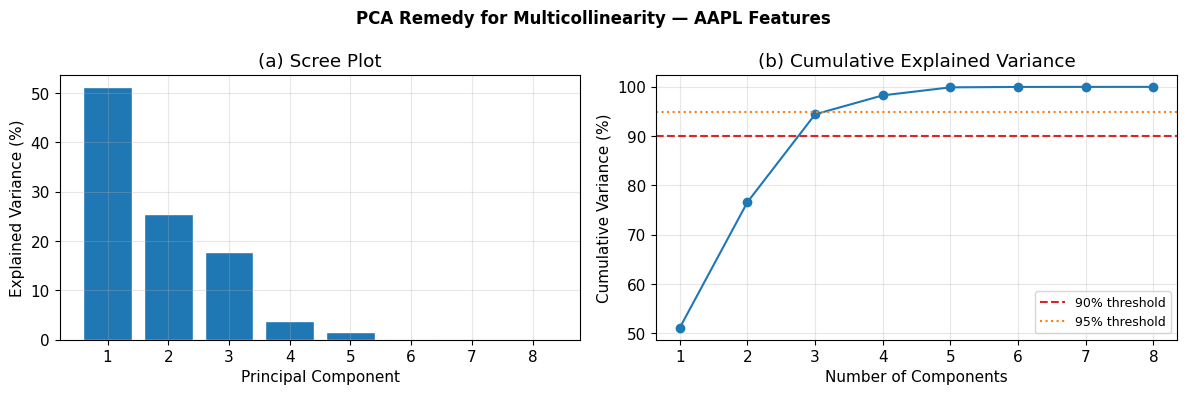

In [17]:
pca_mc  = PCA()
pca_mc.fit(X_mc_sc)
exp_var = np.cumsum(pca_mc.explained_variance_ratio_)

n90 = int(np.argmax(exp_var >= 0.90)) + 1
n95 = int(np.argmax(exp_var >= 0.95)) + 1

print('PCA Dimensionality Reduction')
print(f'  Original features         : {len(features)}')
print(f'  Components for 90% var    : {n90}')
print(f'  Components for 95% var    : {n95}')
print(f'  Explained var per PC      : {np.round(pca_mc.explained_variance_ratio_, 4)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA Remedy for Multicollinearity — AAPL Features',
             fontsize=12, fontweight='bold')

axes[0].bar(range(1, len(features)+1), pca_mc.explained_variance_ratio_*100,
            color=C_MAIN, edgecolor='white')
axes[0].set_title('(a) Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1, len(features)+1), exp_var*100, 'o-', color=C_MAIN)
axes[1].axhline(90, color=C_WARN,   linestyle='--', label='90% threshold')
axes[1].axhline(95, color=C_ACCENT, linestyle=':',  label='95% threshold')
axes[1].set_title('(b) Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Recommended approaches:**
- **Ridge Regression (L2 regularisation):** Stabilises coefficient estimates by adding a penalty; select lambda via time-series CV.
- **Principal Component Analysis (PCA):** Project correlated predictors onto orthogonal components, retaining those explaining 90%+ variance.
- **Feature pruning:** Remove one of every pair with |r| > 0.9; keep the more economically interpretable variable.
- **Partial Least Squares (PLS):** Finds latent components that maximise covariance with the response — effective for highly collinear factor sets.

---

---
# Executive Summary
---

In [18]:
deg20_r2  = float(res_df[res_df.degree == 20]['R2_test'].values[0])
max_vif   = float(vif_data['VIF'].max())
n_out     = len(outliers_z)
pct_out   = n_out / len(r_series) * 100

summary = pd.DataFrame({
    'Challenge': ['Skewness', 'Sensitivity to Outliers', 'Overfitting', 'Multicollinearity'],
    'Key Diagnostic': [
        f'Skewness = {skew_val:.3f}  |  JB p-val ~ 0',
        f'{n_out} outliers ({pct_out:.1f}%) via |Z|>3',
        f'Degree-20 test R2 = {deg20_r2:.3f}',
        f'Max VIF = {max_vif:.1f}  |  kappa = {cond_number:.1f}'
    ],
    'Status': [
        'Significant left skew detected',
        'Extreme events present in sample',
        'Model variance explodes at high degree',
        'Severe collinearity in MA features'
    ],
    'Recommended Remedy': [
        'Skewed-t GARCH / Cornish-Fisher VaR',
        'Robust Regression / GARCH-t / Winsorization',
        'Ridge/Lasso + Walk-Forward CV / GARCH(1,1)',
        'Ridge / PCA / Feature Pruning'
    ]
})

print('=' * 100)
print('  FINANCIAL ECONOMETRICS PROJECT 1 - EXECUTIVE SUMMARY')
print('  Asset: AAPL  |  Source: Yahoo Finance  |  Period: 2018-01-01 to 2025-12-31')
print('=' * 100)
print(summary.to_string(index=False))
print('=' * 100)

  FINANCIAL ECONOMETRICS PROJECT 1 - EXECUTIVE SUMMARY
  Asset: AAPL  |  Source: Yahoo Finance  |  Period: 2018-01-01 to 2025-12-31
              Challenge                     Key Diagnostic                                 Status                          Recommended Remedy
               Skewness Skewness = -0.085  |  JB p-val ~ 0         Significant left skew detected         Skewed-t GARCH / Cornish-Fisher VaR
Sensitivity to Outliers       31 outliers (1.5%) via |Z|>3       Extreme events present in sample Robust Regression / GARCH-t / Winsorization
            Overfitting      Degree-20 test R2 = -2284.329 Model variance explodes at high degree  Ridge/Lasso + Walk-Forward CV / GARCH(1,1)
      Multicollinearity Max VIF = 3166.2  |  kappa = 143.9     Severe collinearity in MA features               Ridge / PCA / Feature Pruning


---
# References
---

1. Tsay, Ruey S. *Analysis of Financial Time Series.* 3rd ed., Wiley, 2010.

2. Bollerslev, Tim. "Generalized Autoregressive Conditional Heteroskedasticity." *Journal of Econometrics*, vol. 31, no. 3, 1986, pp. 307-327.

3. Cornish, E. A., and R. A. Fisher. "Moments and Cumulants in the Specification of Distributions." *Revue de l'Institut International de Statistique*, vol. 5, no. 4, 1938, pp. 307-320.

4. Hoerl, Arthur E., and Robert W. Kennard. "Ridge Regression: Biased Estimation for Nonorthogonal Problems." *Technometrics*, vol. 12, no. 1, 1970, pp. 55-67.

5. Yahoo Finance. *Apple Inc. (AAPL) Historical Data.* finance.yahoo.com/quote/AAPL/history/. Accessed May 2026.

6. Pedregosa, F., et al. "Scikit-learn: Machine Learning in Python." *Journal of Machine Learning Research*, vol. 12, 2011, pp. 2825-2830.

---
*Notebook prepared for HASTS 201 - Financial Econometrics, Project 1.*